# Empirical Evaluation of a Dueling Double-DQN Ramp-Metering Controller with Variable Speed Limit Augmentation

This notebook is the empirical backbone of **Chapter 6 — Results, Analysis & Discussion** of the thesis.
It compares **six controllers** on a seeded set of 50 demand episodes and walks the reader from
"did the agent train?" through "is the new actuator the cause of the improvement?" to
"is the result robust and free of side-effects?".

## Outline

1. **Setup & Configuration**
2. **Data Loading, Schema Audit & Pairing Integrity**
3. **Evaluation Framework** (methodology recap)
4. **Training Dynamics & Convergence**
5. **Aggregate Performance Comparison**
6. **Ablation Study — Isolating the VSL Contribution**
7. **Statistical Comparison vs Classical Baselines**
8. **Demand-Conditioned Performance**
9. **Policy Behavioral Analysis & Merge-Corridor Hypothesis**
10. **Externalities, Safety & Robustness**
11. **Multi-objective Trade-off & Pareto Analysis**
12. **Discussion & Synthesis**

Every figure and table is rendered inline (no files are written to disk).

## 1. Setup & Configuration

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy import stats

BENCHMARKS_DIR      = (Path(".") / "../benchmarks").resolve()
LEARNING_CURVES_DIR = (Path(".") / "../learning_curves").resolve()

sns.set_theme(context="paper", style="whitegrid", palette="deep")
plt.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["DejaVu Serif", "STIXGeneral", "Liberation Serif"],
    "mathtext.fontset":  "stix",
    "axes.titlesize":    11,
    "axes.labelsize":    10,
    "legend.fontsize":   8,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
    "figure.figsize":    (4.5, 3.2),
    "grid.linestyle":    "--",
    "grid.color":        "0.85",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

### 1.1 — Strategy catalog and canonical roles

Six controllers are evaluated. Two are learned (Dueling Double DQN); four are classical.
`RM_VSL` is the proposed method; `RM_ONLY` is the ablation control.

In [2]:
# (display name, csv filename, color, role)
STRATEGY_CATALOG = [
    ("No Control",   "results_AlwaysGreenBaseline.csv", "#aec7e8", "classical"),
    ("Fixed-Control","results_FixedCycleBaseline.csv",  "#17becf", "classical"),
    ("ALINEA",       "results_AlineaDsBaseline.csv",    "#7f7f7f", "classical"),
    ("PI-ALINEA",    "results_PiAlineaDsBaseline.csv",  "#bcbd22", "classical"),
    ("RM-Only",      "results_DQNAgent_rm_only_macro.csv",   "#d62728", "learned-ablation"),
    ("RM+BinaryVSL",       "rm_lcc_setMaxSpeed.csv",          "#2ca02c", "learned-proposed"),
    ("RM+MultiLevelVSL","results_DQNAgent_joint_rm_vsl_42.csv","#9e9e9e","learned-proposed"),
]
ALL_STRATEGIES  = [n for n, _, _, _ in STRATEGY_CATALOG]
STRATEGY_FILES  = {n: str(BENCHMARKS_DIR / f) for n, f, _, _ in STRATEGY_CATALOG}
STRATEGY_COLORS = {n: c for n, _, c, _ in STRATEGY_CATALOG}
STRATEGY_ROLES  = {n: r for n, _, _, r in STRATEGY_CATALOG}

RM_VSL_NAME    = "RM+MultiLevelVSL"
RM_ONLY_NAME   = "RM-Only"
BASELINE_NAMES = ["No Control", "Fixed-Control", "ALINEA", "PI-ALINEA"]
FOCUS_STRATEGY = RM_VSL_NAME

### 1.2 — Metric groups

KPIs are organised in four groups that mirror the thesis methodology:

- **Efficiency** — total/per-vehicle travel time, delay, queue and spillback indicators
- **Traffic state** — speeds and occupancies at the upstream / merge / downstream detectors
- **Actuator usage** — VSL engagement signals (joint variant only)
- **Externalities** — emissions, fuel, safety events

In [3]:
EFFICIENCY_METRICS = {
    "total_travel_time":                 "Total Travel Time (s)",
    "avg_time_loss":                     "Average Delay (s/veh)",
    "avg_ramp_queue_veh":                "Average Ramp Queue (veh)",
    "total_spillback_time_sec":          "Total Spillback Time (s)",
    "avg_mainline_speed_mergeArea_km/h": "Merge-area Mean Speed (km/h)",
    "total_co2_mg":                      r"Total CO2 Emissions (mg)",
}

TRAFFIC_STATE_METRICS = {
    "avg_mainline_occ_upstream_percent":   "Upstream Occupancy (%)",
    "avg_mainline_occ_mergeArea_percent":  "Merge-area Occupancy (%)",
    "avg_mainline_occ_downstream_percent": "Downstream Occupancy (%)",
    "avg_mainline_speed_upstream_km/h":    "Upstream Speed (km/h)",
    "avg_mainline_speed_downstream_km/h":  "Downstream Speed (km/h)",
}

ACTUATOR_METRICS = {
    "lane_closure_rate":  "VSL Engagement Rate",
    "lane_closure_steps": "VSL Engagement Steps",
}

EXTERNALITY_METRICS = {
    "total_co2_mg":            r"Total CO2 (mg)",
    "total_fuel_ml":           "Total Fuel (ml)",
    "total_nox_mg":            r"Total NO$_x$ (mg)",
    "num_emergency_stops":     "Emergency Stops",
    "num_teleported_tripinfo": "Teleports",
}

HIGHER_IS_BETTER = {
    "avg_mainline_speed_mergeArea_km/h",
    "avg_mainline_speed_upstream_km/h",
    "avg_mainline_speed_downstream_km/h",
}

MAINLINE_LEVELS = ["Low Mainline", "Medium Mainline", "High Mainline"]
RAMP_LEVELS     = ["Low On-Ramp",  "Medium On-Ramp",  "High On-Ramp"]

## 2. Data Loading, Schema Audit & Pairing Integrity

### 2.1 — Helpers

Shared utilities used throughout the notebook. They are intentionally tiny so each later cell stays readable.

In [4]:
def metric_sort_ascending(metric_key: str) -> bool:
    return metric_key not in HIGHER_IS_BETTER


def pct_improvement(focus_val: float, other_val: float, metric_key: str) -> float:
    """Positive => focus is better than other."""
    if other_val == 0 or not np.isfinite(other_val):
        return np.nan
    if metric_key in HIGHER_IS_BETTER:
        return ((focus_val - other_val) / other_val) * 100
    return ((other_val - focus_val) / other_val) * 100


def normalize_metric(series: pd.Series, metric_key: str) -> pd.Series:
    """Min-max to [0, 1] with 1 = best regardless of direction."""
    lo, hi = series.min(), series.max()
    if hi == lo:
        return pd.Series(np.ones_like(series, dtype=float), index=series.index)
    scaled = (series - lo) / (hi - lo)
    return scaled if metric_key in HIGHER_IS_BETTER else 1 - scaled


def load_benchmarks() -> pd.DataFrame:
    frames = []
    for strategy, filepath in STRATEGY_FILES.items():
        p = Path(filepath)
        if not p.is_file():
            print(f"Warning: missing '{p.name}' -> skipping {strategy}.")
            continue
        f = pd.read_csv(p)
        f.columns = f.columns.str.strip()
        f["strategy"] = strategy
        frames.append(f)
    if not frames:
        raise RuntimeError("No benchmark CSVs loaded.")
    return pd.concat(frames, ignore_index=True)


def categorize_demand(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["mainline_demand"] = pd.cut(df["main_flow_vph"],
        bins=[0, 4750, 5750, float("inf")], labels=MAINLINE_LEVELS, right=False)
    df["on_ramp_demand"]  = pd.cut(df["on_ramp_flow_vph"],
        bins=[0, 1600, 1800, float("inf")], labels=RAMP_LEVELS, right=False)
    df["demand_cell"] = (df["mainline_demand"].astype(str) + " / "
                         + df["on_ramp_demand"].astype(str))
    return df


def paired_join(strat_a: str, strat_b: str, df: pd.DataFrame) -> pd.DataFrame:
    """Inner-join two strategies on (episode_id, seed). Returns row-aligned frame."""
    a = df[df.strategy == strat_a].set_index(["episode_id", "seed"]).sort_index()
    b = df[df.strategy == strat_b].set_index(["episode_id", "seed"]).sort_index()
    joined = a.join(b, lsuffix="_a", rsuffix="_b", how="inner")
    return joined


def paired_summary(joined: pd.DataFrame, metric_key: str) -> dict:
    """For a paired frame, return ablation-style stats: Δ̄, σ_Δ, %imp, Wilcoxon p, win count."""
    a = joined[f"{metric_key}_a"].astype(float)
    b = joined[f"{metric_key}_b"].astype(float)
    # Sign so positive delta = A improves on B for every metric
    delta = (a - b) if metric_key in HIGHER_IS_BETTER else (b - a)
    n = len(delta)
    n_wins   = int((delta > 0).sum())
    n_losses = int((delta < 0).sum())
    n_ties   = int((delta == 0).sum())
    pct = pct_improvement(a.mean(), b.mean(), metric_key)
    # Wilcoxon needs at least one non-zero diff
    try:
        if (delta != 0).any():
            _, p = stats.wilcoxon(delta, zero_method="wilcox", alternative="two-sided")
        else:
            p = np.nan
    except ValueError:
        p = np.nan
    return {
        "mean_delta":  float(delta.mean()),
        "std_delta":   float(delta.std(ddof=1)) if n > 1 else np.nan,
        "pct_improvement": float(pct),
        "wilcoxon_p":  float(p) if p is not None else np.nan,
        "n_wins":      n_wins, "n_losses": n_losses, "n_ties": n_ties, "n": n,
    }


def pearson_r(x: np.ndarray, y: np.ndarray) -> tuple[float, float]:
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3:
        return (np.nan, np.nan)
    r, p = stats.pearsonr(x[mask], y[mask])
    return float(r), float(p)


def significance_stars(p: float) -> str:
    if not np.isfinite(p): return "n/a"
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"


def style_signed_pct(v: float) -> str:
    return f"{v:+.2f}%" if np.isfinite(v) else "n/a"


FOCUS_COLOR = "#111111"   # accent for the focus controller in head-to-head plots

### 2.2 — Load benchmarks and audit the schema

Every CSV is read with permissive headers; the resulting frame is augmented with demand bins.
The audit table flags which metric columns are populated per controller — `lane_closure_*`
is expected only for the joint RM+VSL run.

In [5]:
df = categorize_demand(load_benchmarks())
present_strategies = [s for s in ALL_STRATEGIES if s in df["strategy"].unique()]
print(f"Loaded {len(df):,} rows across {len(present_strategies)} controllers.\n")

roster = (df.groupby("strategy", sort=False).size()
            .rename("episodes").reindex(present_strategies).to_frame())
roster["role"] = roster.index.map(STRATEGY_ROLES)
display(Markdown("**Roster — episode counts and canonical role per controller**"))
display(roster.style.set_caption("Loaded benchmark CSVs"))

Loaded 350 rows across 7 controllers.



**Roster — episode counts and canonical role per controller**

,episodes,role
strategy,,
No Control,50,classical
Fixed-Control,50,classical
ALINEA,50,classical
PI-ALINEA,50,classical
RM-Only,50,learned-ablation
RM+BinaryVSL,50,learned-proposed
RM+MultiLevelVSL,50,learned-proposed


In [6]:
audit_cols = (
    list(EFFICIENCY_METRICS) + list(TRAFFIC_STATE_METRICS)
    + list(ACTUATOR_METRICS) + list(EXTERNALITY_METRICS)
)
audit_cols = list(dict.fromkeys(audit_cols))  # de-dupe while preserving order

audit = pd.DataFrame(index=present_strategies, columns=audit_cols, dtype=float)
for s in present_strategies:
    sub = df[df.strategy == s]
    for col in audit_cols:
        if col not in sub.columns:
            audit.loc[s, col] = np.nan
        else:
            audit.loc[s, col] = float(sub[col].notna().mean())

display(Markdown("**Schema audit — fraction of non-null episodes per (controller, metric).** "
                 "Empty cells indicate the column is absent for that controller."))
display(
    audit.style
    .format("{:.0%}", na_rep="—")
    .background_gradient(cmap="Greens", vmin=0, vmax=1, axis=None)
    .set_caption("1.00 means every episode reported the metric")
)

**Schema audit — fraction of non-null episodes per (controller, metric).** Empty cells indicate the column is absent for that controller.

,total_travel_time,avg_time_loss,avg_ramp_queue_veh,total_spillback_time_sec,avg_mainline_speed_mergeArea_km/h,total_co2_mg,avg_mainline_occ_upstream_percent,avg_mainline_occ_mergeArea_percent,avg_mainline_occ_downstream_percent,avg_mainline_speed_upstream_km/h,avg_mainline_speed_downstream_km/h,lane_closure_rate,lane_closure_steps,total_fuel_ml,total_nox_mg,num_emergency_stops,num_teleported_tripinfo
No Control,100%,100%,100%,100%,100%,100%,100%,100%,100%,100%,100%,0%,0%,100%,100%,100%,100%
Fixed-Control,100%,100%,100%,100%,100%,100%,100%,100%,100%,100%,100%,0%,0%,100%,100%,100%,100%
ALINEA,100%,100%,100%,100%,100%,100%,100%,100%,100%,100%,100%,0%,0%,100%,100%,100%,100%
PI-ALINEA,100%,100%,100%,100%,100%,100%,100%,100%,100%,100%,100%,0%,0%,100%,100%,100%,100%
RM-Only,100%,100%,100%,100%,100%,100%,100%,100%,100%,100%,100%,0%,0%,100%,100%,100%,100%
RM+BinaryVSL,100%,100%,98%,98%,98%,100%,98%,98%,98%,98%,98%,98%,98%,100%,100%,98%,100%
RM+MultiLevelVSL,100%,100%,100%,100%,100%,100%,100%,100%,100%,100%,100%,0%,0%,100%,100%,100%,100%


### 2.3 — Pairing integrity

Every controller is evaluated on the **same** 50 `(episode_id, seed)` pairs. We assert that
explicitly so later paired tests are correct.

In [7]:
ref_pairs = set(zip(df[df.strategy == present_strategies[0]].episode_id,
                    df[df.strategy == present_strategies[0]].seed))
overlap_rows = []
for s in present_strategies:
    pairs = set(zip(df[df.strategy == s].episode_id, df[df.strategy == s].seed))
    overlap_rows.append({
        "Controller":  s,
        "n_episodes":  len(pairs),
        "Shared with reference": len(pairs & ref_pairs),
        "Unique to controller":  len(pairs - ref_pairs),
        "Missing from controller": len(ref_pairs - pairs),
    })
overlap_df = pd.DataFrame(overlap_rows).set_index("Controller")
display(Markdown(f"**Reference controller**: `{present_strategies[0]}` "
                 f"with {len(ref_pairs)} (episode_id, seed) pairs."))
display(overlap_df.style.set_caption("Pairing integrity across the six controllers"))

all_match = (overlap_df["Shared with reference"] == len(ref_pairs)).all() \
            and (overlap_df["Unique to controller"] == 0).all()
print("Pairing integrity:", "OK — every controller covers the same 50 episodes."
      if all_match else "WARNING — overlap differs across controllers.")

**Reference controller**: `No Control` with 50 (episode_id, seed) pairs.

,n_episodes,Shared with reference,Unique to controller,Missing from controller
Controller,,,,
No Control,50,50,0,0
Fixed-Control,50,50,0,0
ALINEA,50,50,0,0
PI-ALINEA,50,50,0,0
RM-Only,50,50,0,0
RM+BinaryVSL,50,50,0,0
RM+MultiLevelVSL,50,50,0,0


Pairing integrity: OK — every controller covers the same 50 episodes.


## 3. Evaluation Framework

This section is the methodology recap — it pins down what every later number means.

**Six controllers** are compared:

| Role               | Name              | Description                                           |
| ------------------ | ----------------- | ----------------------------------------------------- |
| open-loop baseline | **No Control**    | Ramp signal permanently green                         |
| naive cyclic       | **Fixed-Control** | Fixed 20 s green / 20 s red                           |
| classical feedback | **ALINEA**        | Proportional feedback on downstream occupancy         |
| classical PI       | **PI-ALINEA**     | Proportional-integral variant                         |
| learned (ablation) | **RM-Only**       | Dueling Double DQN, ramp meter only                   |
| learned (proposed) | **RM+VSL**        | Dueling Double DQN, ramp meter + variable speed limit |

**Episode design.** Every controller runs on the same 50 seeded demand episodes
(`seed = master_seed + episode_id`). This pairs every metric value across controllers,
so paired statistics (mean Δ, Wilcoxon signed-rank) can attribute differences to the
controller and not to traffic variance.

**Metric groups.**

- _Efficiency_ — `total_travel_time`, `avg_time_loss`, `avg_ramp_queue_veh`,
  `total_spillback_time_sec`, `avg_mainline_speed_mergeArea_km/h`, `total_co2_mg`.
  Higher is better only for the merge-area speed; lower is better for all others.
- _Traffic state_ — per-cycle averages at the upstream / merge / downstream detectors.
- _Actuator usage_ — `lane_closure_rate`, `lane_closure_steps` (RM+VSL only).
- _Externalities_ — `total_fuel_ml`, `total_nox_mg`, `num_emergency_stops`,
  `num_teleported_tripinfo` and CO$_2$.

**Direction convention.** Throughout the notebook, **a positive Δ or % improvement
always means RM+VSL is better** (sign is flipped automatically for higher-is-better metrics).

## 4. Training Dynamics & Convergence

The learning curves below were exported from TensorBoard during training. Each file
in `evaluation/learning_curves/` corresponds to one training run, with a `(Step, Value)`
schema. Curves are shown as the raw trace (faded) plus an exponentially-smoothed signal
(α = 0.05). The final-10 % window is shaded; its mean is annotated as the **plateau value**.

In [8]:
def load_training_curves() -> dict[str, pd.DataFrame]:
    out: dict[str, pd.DataFrame] = {}
    if not LEARNING_CURVES_DIR.is_dir():
        return out
    for path in sorted(LEARNING_CURVES_DIR.glob("*.csv")):
        try:
            curve = pd.read_csv(path)
        except Exception as exc:
            print(f"Could not read {path.name}: {exc}")
            continue
        curve.columns = curve.columns.str.strip()
        if not {"Step", "Value"}.issubset(curve.columns):
            print(f"Skipping {path.name}: missing Step/Value columns.")
            continue
        out[path.stem] = curve.sort_values("Step").reset_index(drop=True)
    return out


def ema(series: pd.Series, alpha: float = 0.05) -> pd.Series:
    return series.ewm(alpha=alpha, adjust=False).mean()


training_curves = load_training_curves()
print(f"Found {len(training_curves)} training curve file(s):")
for name, frame in training_curves.items():
    print(f"  - {name}: {len(frame)} samples, "
          f"Step range [{frame.Step.min()}, {frame.Step.max()}]")

Found 2 training curve file(s):
  - learning-curve-rm-vsl-42: 466 samples, Step range [4500, 2097000]
  - learning-curve: 466 samples, Step range [4500, 2097000]


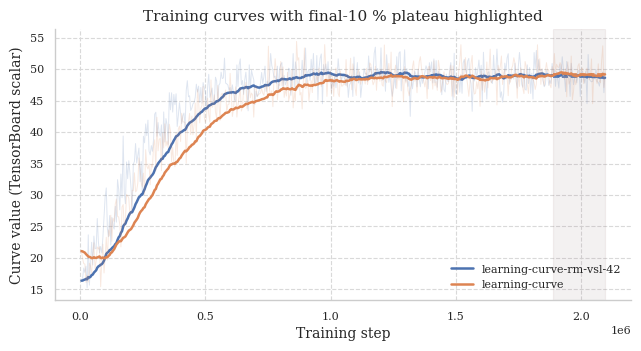

In [9]:
if not training_curves:
    display(Markdown("_No training curve CSV found in `evaluation/learning_curves/`._"))
else:
    fig, ax = plt.subplots(figsize=(6.5, 3.6))
    palette = sns.color_palette("deep", n_colors=len(training_curves))
    for color, (name, frame) in zip(palette, training_curves.items()):
        ax.plot(frame.Step, frame.Value, color=color, alpha=0.18, linewidth=0.7)
        ax.plot(frame.Step, ema(frame.Value), color=color, linewidth=1.8, label=name)
        cutoff = frame.Step.quantile(0.9)
        tail = frame[frame.Step >= cutoff]
        ax.axvspan(cutoff, frame.Step.max(), color=color, alpha=0.05)
        ax.hlines(tail.Value.mean(), cutoff, frame.Step.max(),
                  colors=color, linestyles="--", linewidth=1.2)
    ax.set_title("Training curves with final-10 % plateau highlighted")
    ax.set_xlabel("Training step")
    ax.set_ylabel("Curve value (TensorBoard scalar)")
    ax.legend(loc="lower right", frameon=False)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [10]:
if training_curves:
    rows = []
    for name, frame in training_curves.items():
        cutoff = frame.Step.quantile(0.9)
        tail = frame[frame.Step >= cutoff].Value
        head = frame[frame.Step < cutoff].Value
        # slope across the full curve
        slope = np.polyfit(frame.Step, frame.Value, 1)[0] if len(frame) >= 2 else np.nan
        rows.append({
            "Run":               name,
            "Total steps":       int(frame.Step.max()),
            "Plateau mean":      float(tail.mean()),
            "Plateau std":       float(tail.std(ddof=1)) if len(tail) > 1 else np.nan,
            "Pre-plateau mean":  float(head.mean()),
            "Linear slope":      float(slope),
            "Stable?":           "yes" if abs(slope) < 1e-7 else "drifting",
        })
    conv_df = pd.DataFrame(rows).set_index("Run")
    display(Markdown("**Convergence summary** — plateau computed on the final 10 % of steps."))
    display(conv_df.style.format({
        "Plateau mean": "{:.3f}", "Plateau std": "{:.3f}",
        "Pre-plateau mean": "{:.3f}", "Linear slope": "{:.2e}",
    }))

**Convergence summary** — plateau computed on the final 10 % of steps.

,Total steps,Plateau mean,Plateau std,Pre-plateau mean,Linear slope,Stable?
Run,,,,,,
learning-curve-rm-vsl-42,2097000,48.769,1.581,45.091,8.25e-06,drifting
learning-curve,2097000,49.234,1.847,43.709,1.02e-05,drifting


## 5. Aggregate Performance Comparison

The headline view: how do the six controllers stack up across the efficiency KPIs?
The mean ± std table is the publication artifact; the bar / violin / radar plots
support the same conclusion from different angles.

In [11]:
strategy_means = (
    df.groupby("strategy", sort=False)[list(EFFICIENCY_METRICS)]
      .mean().reindex(present_strategies)
)
strategy_stds = (
    df.groupby("strategy", sort=False)[list(EFFICIENCY_METRICS)]
      .std(ddof=1).reindex(present_strategies)
)

In [12]:
def best_row_mask(means: pd.DataFrame) -> pd.DataFrame:
    mask = pd.DataFrame(False, index=means.index, columns=means.columns)
    for col in means.columns:
        if col in HIGHER_IS_BETTER:
            best_idx = means[col].idxmax()
        else:
            best_idx = means[col].idxmin()
        mask.loc[best_idx, col] = True
    return mask

cells_str = strategy_means.copy().astype(object)
for col in strategy_means.columns:
    for s in strategy_means.index:
        cells_str.loc[s, col] = (
            f"{strategy_means.loc[s, col]:,.2f} ± {strategy_stds.loc[s, col]:,.2f}"
        )
cells_str.columns = [EFFICIENCY_METRICS[c] for c in cells_str.columns]

best_mask = best_row_mask(strategy_means)
best_mask.columns = cells_str.columns

def emphasize(val, is_best):
    return f"<b>{val}</b>" if is_best else val
for col in cells_str.columns:
    cells_str[col] = [emphasize(v, b) for v, b in zip(cells_str[col], best_mask[col])]

display(Markdown("**Mean ± std of efficiency KPIs across 50 episodes** "
                 "(best controller per column in **bold**)"))
display(cells_str.style.set_caption("Aggregate performance — 6 controllers × 6 KPIs"))

**Mean ± std of efficiency KPIs across 50 episodes** (best controller per column in **bold**)

,Total Travel Time (s),Average Delay (s/veh),Average Ramp Queue (veh),Total Spillback Time (s),Merge-area Mean Speed (km/h),Total CO2 Emissions (mg)
strategy,,,,,,
No Control,"576,047.16 ± 72,888.66",57.21 ± 11.74,10.06 ± 0.93,1.40 ± 4.17,12.62 ± 0.27,"1,822,323,144.65 ± 127,346,842.34"
Fixed-Control,"386,182.16 ± 54,170.77",23.52 ± 7.96,15.57 ± 0.14,1.58 ± 3.24,14.18 ± 0.48,"1,576,992,817.73 ± 131,266,468.16"
ALINEA,"417,836.80 ± 39,705.29",27.53 ± 5.07,14.18 ± 2.26,381.30 ± 169.74,13.41 ± 0.17,"1,646,573,304.66 ± 101,502,560.14"
PI-ALINEA,"426,418.10 ± 45,185.76",29.10 ± 6.05,14.28 ± 2.17,625.28 ± 199.77,13.48 ± 0.16,"1,656,096,458.08 ± 108,898,492.57"
RM-Only,"372,429.18 ± 29,820.58",19.60 ± 3.35,14.08 ± 2.14,90.40 ± 92.78,15.37 ± 0.34,"1,580,972,869.32 ± 89,031,376.39"
RM+BinaryVSL,"365,281.02 ± 26,859.15",19.28 ± 2.95,15.54 ± 2.25,145.31 ± 149.60,16.00 ± 0.23,"1,557,039,429.11 ± 81,274,595.83"
RM+MultiLevelVSL,"370,533.54 ± 27,853.27",19.33 ± 2.98,14.45 ± 2.22,53.60 ± 62.39,15.61 ± 0.28,"1,575,114,051.13 ± 85,295,022.01"


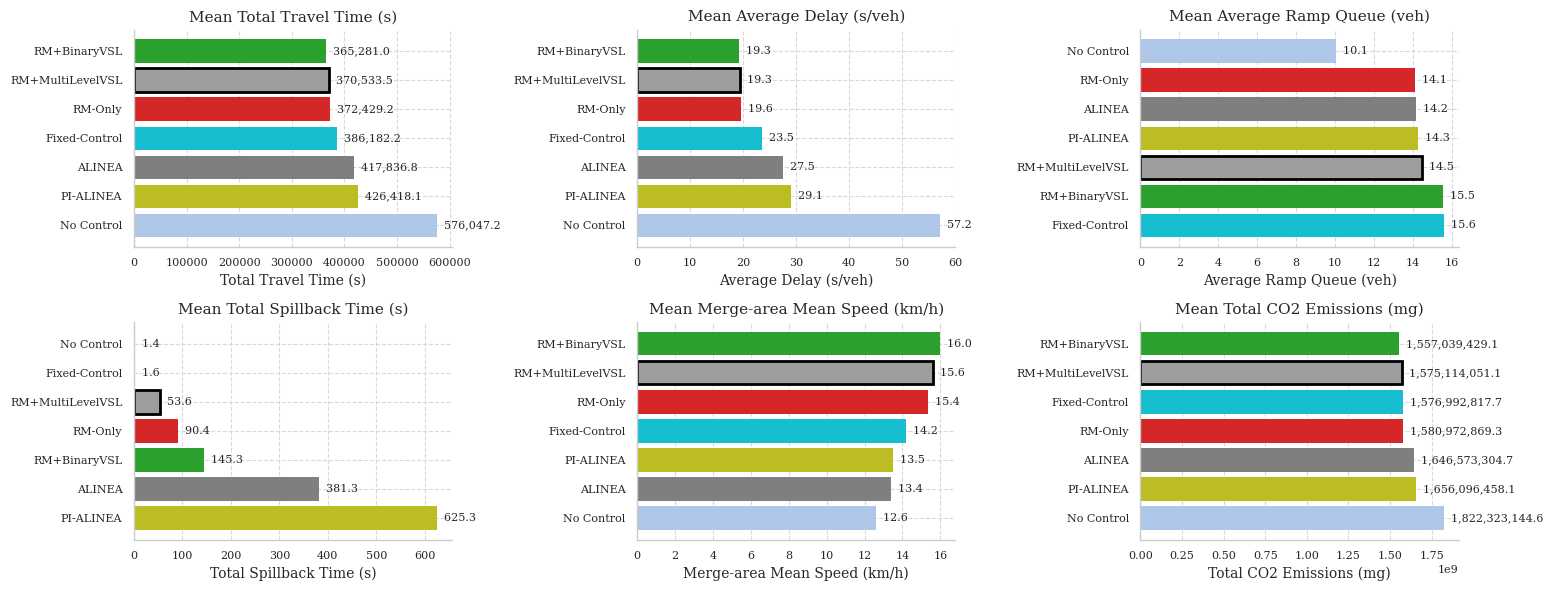

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15.6, 6.0))
axes = axes.flatten()

for ax, (metric_key, metric_name) in zip(axes, EFFICIENCY_METRICS.items()):
    ordered = strategy_means[metric_key].sort_values(
        ascending=metric_sort_ascending(metric_key))
    colors = [STRATEGY_COLORS[s] for s in ordered.index]
    edges  = ["black" if s == FOCUS_STRATEGY else "none" for s in ordered.index]
    widths = [2.0     if s == FOCUS_STRATEGY else 0      for s in ordered.index]

    ax.barh(ordered.index, ordered.values, color=colors, edgecolor=edges, linewidth=widths)
    ax.set_title(f"Mean {metric_name}")
    ax.set_xlabel(metric_name); ax.set_ylabel("")
    ax.invert_yaxis()
    for s, v in ordered.items():
        ax.text(v, list(ordered.index).index(s), f"  {v:,.1f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()
plt.close(fig)

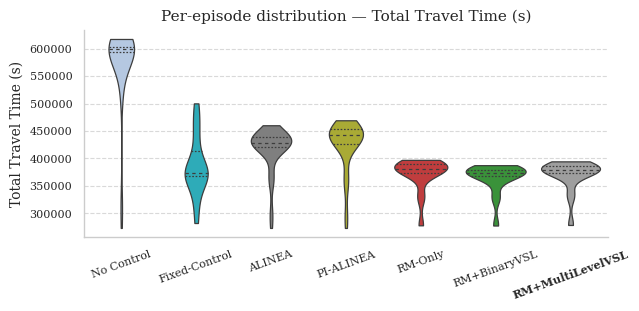

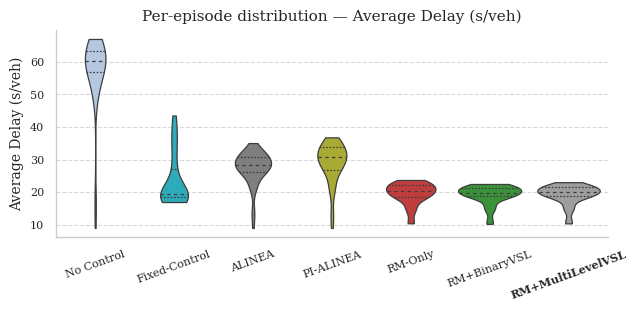

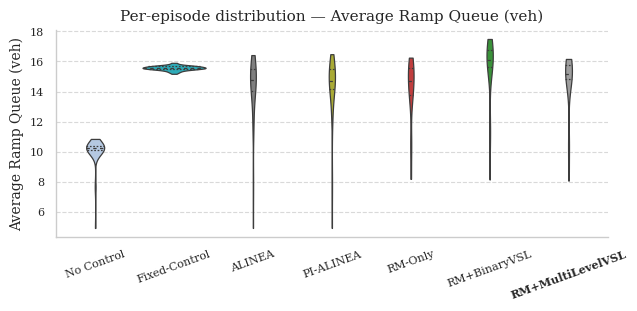

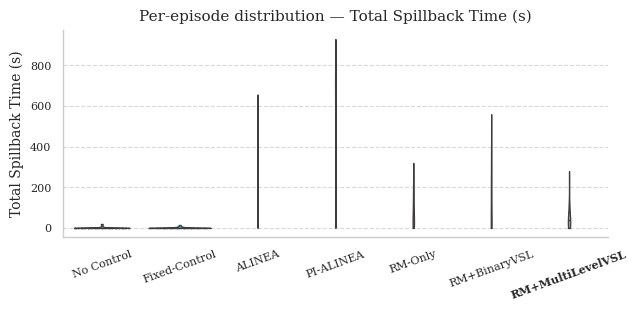

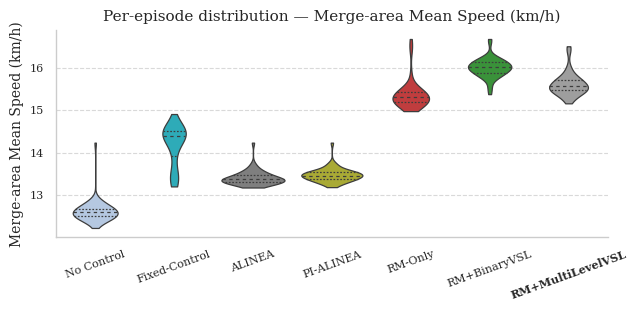

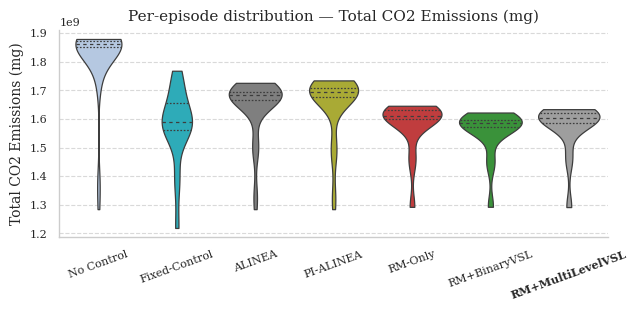

In [14]:
df_ord = df.copy()
df_ord["strategy"] = pd.Categorical(df_ord["strategy"],
                                    categories=present_strategies, ordered=True)
palette = [STRATEGY_COLORS[s] for s in present_strategies]

for metric_key, metric_name in EFFICIENCY_METRICS.items():
    fig, ax = plt.subplots(figsize=(6.5, 3.2))
    sns.violinplot(data=df_ord, x="strategy", y=metric_key,
                   palette=palette, inner="quartile", cut=0, linewidth=0.9, ax=ax)
    ax.set_title(f"Per-episode distribution — {metric_name}")
    ax.set_xlabel(""); ax.set_ylabel(metric_name)
    ax.tick_params(axis="x", rotation=20)
    for label in ax.get_xticklabels():
        if label.get_text() == FOCUS_STRATEGY:
            label.set_fontweight("bold")
    plt.tight_layout(); plt.show(); plt.close(fig)

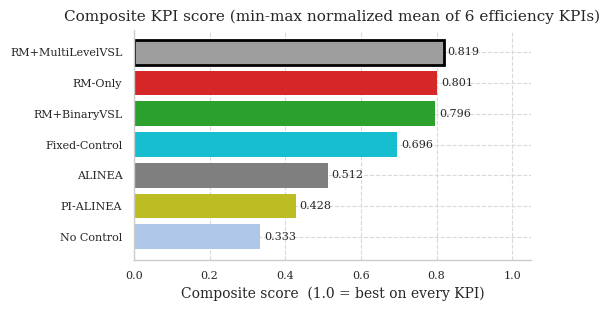

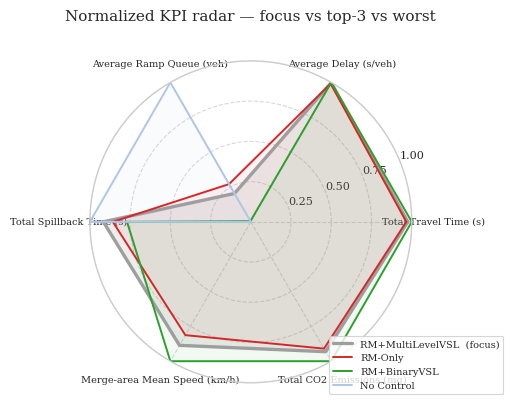

In [15]:
normalized = pd.DataFrame(
    {k: normalize_metric(strategy_means[k], k) for k in EFFICIENCY_METRICS},
    index=strategy_means.index,
)
composite = normalized.mean(axis=1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(5.5, 3.2))
colors = [STRATEGY_COLORS[s] for s in composite.index]
edges  = ["black" if s == FOCUS_STRATEGY else "none" for s in composite.index]
widths = [2.0     if s == FOCUS_STRATEGY else 0      for s in composite.index]
ax.barh(composite.index, composite.values, color=colors, edgecolor=edges, linewidth=widths)
ax.set_title("Composite KPI score (min-max normalized mean of 6 efficiency KPIs)")
ax.set_xlabel("Composite score  (1.0 = best on every KPI)"); ax.invert_yaxis()
ax.set_xlim(0, 1.05)
for s, v in composite.items():
    ax.text(v + 0.01, list(composite.index).index(s), f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout(); plt.show(); plt.close(fig)

# Radar — focus + top 3 + worst (deduped)
sel = [FOCUS_STRATEGY] + list(composite.head(3).index) + [composite.tail(1).index[0]]
sel = list(dict.fromkeys(sel))

labels = [EFFICIENCY_METRICS[k] for k in EFFICIENCY_METRICS]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(5.5, 5.5), subplot_kw=dict(polar=True))
for s in sel:
    vals = normalized.loc[s].tolist(); vals += vals[:1]
    is_focus = s == FOCUS_STRATEGY
    ax.plot(angles, vals, color=STRATEGY_COLORS[s],
            linewidth=2.4 if is_focus else 1.4,
            label=s + ("  (focus)" if is_focus else ""))
    ax.fill(angles, vals, color=STRATEGY_COLORS[s],
            alpha=0.18 if is_focus else 0.06)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels, fontsize=7)
ax.set_yticks([0.25, 0.5, 0.75, 1.0]); ax.set_ylim(0, 1)
ax.set_title("Normalized KPI radar — focus vs top-3 vs worst", y=1.10)
ax.legend(loc="lower right", bbox_to_anchor=(1.30, -0.05), fontsize=7)
plt.tight_layout(); plt.show(); plt.close(fig)

## 6. Ablation Study — Isolating the VSL Contribution

RM+VSL and RM-Only share the same DRL agent and the same set of seeded episodes.
The only thing that differs is whether the VSL actuator is available.
Any persistent paired-Δ therefore isolates **the VSL contribution**.

Sign convention: Δ > 0 means RM+VSL improves on RM-Only on that metric and episode.
We use the Wilcoxon signed-rank test (non-parametric, paired).

In [16]:
ablation_join = paired_join(RM_VSL_NAME, RM_ONLY_NAME, df)
print(f"Paired episodes used for ablation: {len(ablation_join)}  (expect 50)")

ablation_rows = []
for metric_key, metric_name in EFFICIENCY_METRICS.items():
    s = paired_summary(ablation_join, metric_key)
    ablation_rows.append({
        "KPI":              metric_name,
        f"Δ̄ ({RM_VSL_NAME} − {RM_ONLY_NAME})": s["mean_delta"],
        "σ_Δ":              s["std_delta"],
        "% Improvement":    s["pct_improvement"],
        "Wilcoxon p":       s["wilcoxon_p"],
        "Sig.":             significance_stars(s["wilcoxon_p"]),
        "Wins / 50":        s["n_wins"],
    })
ablation_df = pd.DataFrame(ablation_rows).set_index("KPI")
display(Markdown("**Paired ablation — RM+VSL vs RM-Only across 50 episodes.** "
                 "Δ̄ is sign-corrected so positive means improvement. "
                 "Stars: `*` p<0.05, `**` p<0.01, `***` p<0.001."))
display(
    ablation_df.style.format({
        f"Δ̄ ({RM_VSL_NAME} − {RM_ONLY_NAME})": "{:+.3f}",
        "σ_Δ":           "{:.3f}",
        "% Improvement": "{:+.2f}%",
        "Wilcoxon p":    "{:.3g}",
    })
    .background_gradient(cmap="RdYlGn", subset=["% Improvement"], vmin=-30, vmax=30)
)

Paired episodes used for ablation: 50  (expect 50)


**Paired ablation — RM+VSL vs RM-Only across 50 episodes.** Δ̄ is sign-corrected so positive means improvement. Stars: `*` p<0.05, `**` p<0.01, `***` p<0.001.

,Δ̄ (RM+MultiLevelVSL − RM-Only),σ_Δ,% Improvement,Wilcoxon p,Sig.,Wins / 50
KPI,,,,,,
Total Travel Time (s),+1895.640,4397.438,+0.51%,0.00877,**,31
Average Delay (s/veh),+0.271,0.750,+1.38%,0.0349,*,30
Average Ramp Queue (veh),-0.371,0.537,-2.63%,3.24e-05,***,12
Total Spillback Time (s),+36.800,97.592,+40.71%,0.0124,*,22
Merge-area Mean Speed (km/h),+0.247,0.226,+1.61%,2.23e-07,***,42
Total CO2 Emissions (mg),+5858818.193,12142171.786,+0.37%,0.0024,**,34


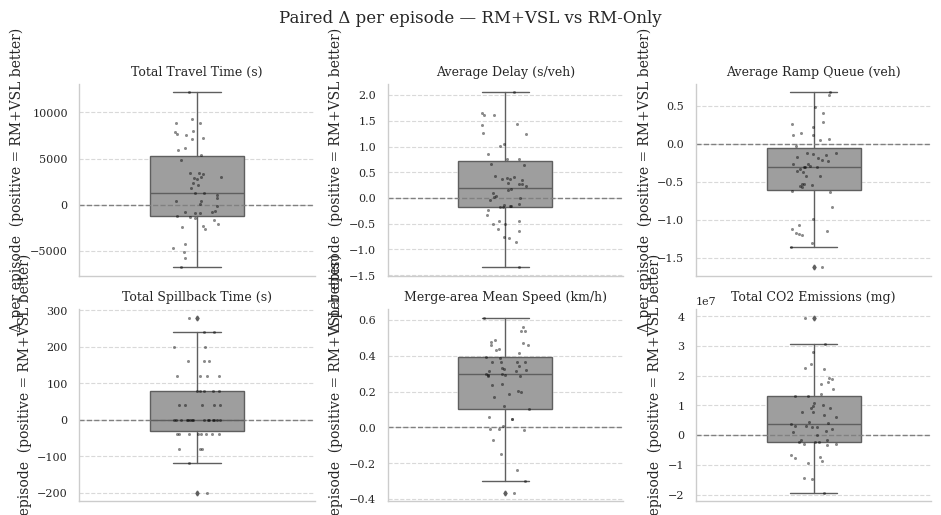

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(9.5, 5.0), sharey=False)
for ax, (metric_key, metric_name) in zip(axes.ravel(), EFFICIENCY_METRICS.items()):
    a = ablation_join[f"{metric_key}_a"]
    b = ablation_join[f"{metric_key}_b"]
    delta = (a - b) if metric_key in HIGHER_IS_BETTER else (b - a)
    sns.boxplot(y=delta, color=STRATEGY_COLORS[RM_VSL_NAME], width=0.4,
                fliersize=2.5, linewidth=1.0, ax=ax)
    sns.stripplot(y=delta, color="black", size=2.2, alpha=0.45, jitter=True, ax=ax)
    ax.axhline(0, color="grey", linestyle="--", linewidth=1)
    ax.set_title(metric_name, fontsize=9)
    ax.set_ylabel("Δ per episode  (positive = RM+VSL better)")
fig.suptitle("Paired Δ per episode — RM+VSL vs RM-Only", y=1.02, fontsize=12)
plt.tight_layout(); plt.show(); plt.close(fig)

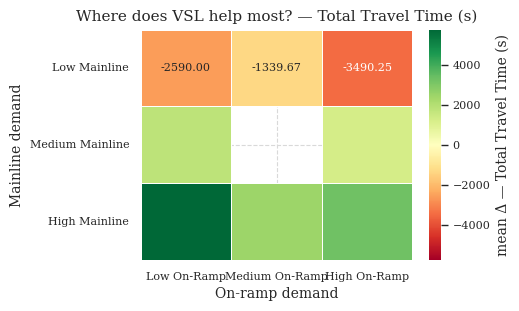

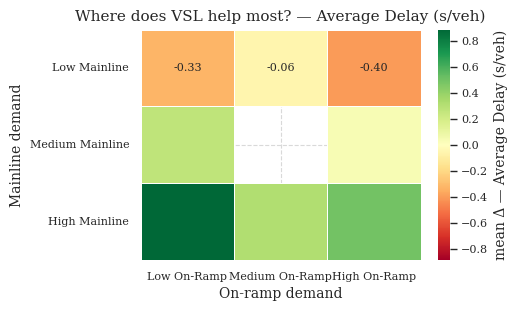

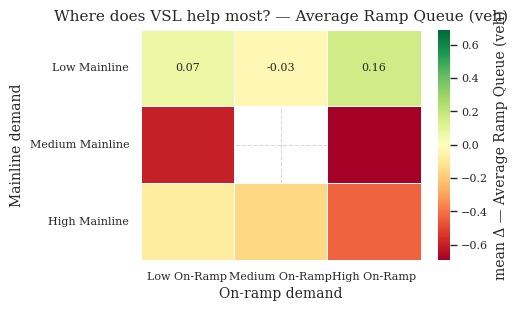

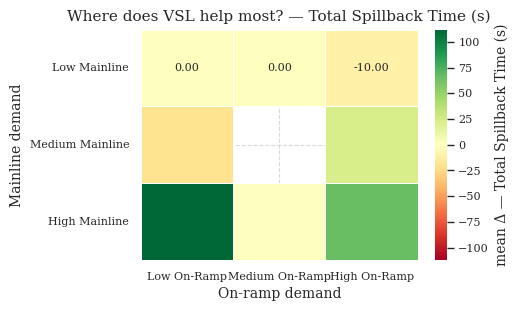

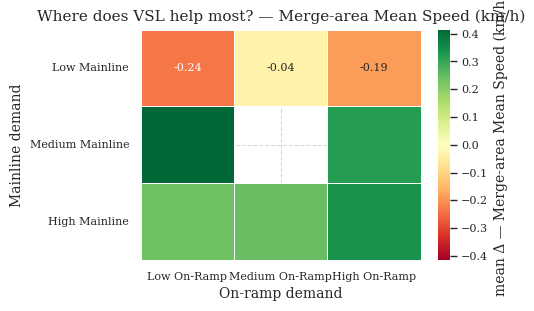

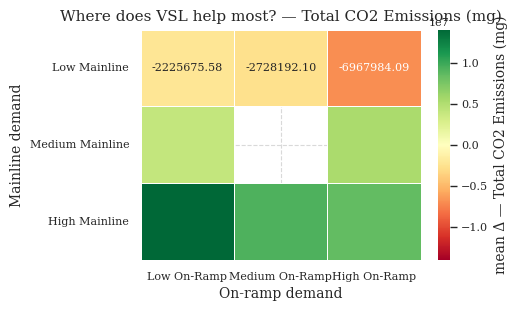

In [18]:
# Per-demand-cell mean Δ heatmap (one per KPI)
demand_cells = [f"{m} / {r}" for m in MAINLINE_LEVELS for r in RAMP_LEVELS]
joined_with_demand = ablation_join.reset_index().merge(
    df[df.strategy == RM_VSL_NAME][["episode_id", "seed", "mainline_demand", "on_ramp_demand"]],
    on=["episode_id", "seed"], how="left",
)
joined_with_demand["demand_cell"] = (
    joined_with_demand["mainline_demand"].astype(str) + " / "
    + joined_with_demand["on_ramp_demand"].astype(str)
)

for metric_key, metric_name in EFFICIENCY_METRICS.items():
    a = joined_with_demand[f"{metric_key}_a"]
    b = joined_with_demand[f"{metric_key}_b"]
    delta = (a - b) if metric_key in HIGHER_IS_BETTER else (b - a)
    joined_with_demand["_delta"] = delta
    pivot = (joined_with_demand.groupby(["mainline_demand", "on_ramp_demand"],
                                        observed=True)["_delta"]
             .mean().unstack("on_ramp_demand")
             .reindex(index=MAINLINE_LEVELS, columns=RAMP_LEVELS))

    fig, ax = plt.subplots(figsize=(5.2, 3.2))
    vmax = float(np.nanmax(np.abs(pivot.values))) if np.isfinite(pivot.values).any() else 1.0
    sns.heatmap(pivot, cmap="RdYlGn", center=0, vmin=-vmax, vmax=vmax,
                annot=True, fmt=".2f", annot_kws={"size": 8},
                linewidths=0.5, linecolor="white",
                cbar_kws={"label": f"mean Δ — {metric_name}"}, ax=ax)
    ax.set_title(f"Where does VSL help most? — {metric_name}")
    ax.set_xlabel("On-ramp demand"); ax.set_ylabel("Mainline demand")
    plt.tight_layout(); plt.show(); plt.close(fig)

## 7. Statistical Comparison vs Classical Baselines

Same paired machinery, now applied between RM+VSL and each of the four classical baselines.
The headline view is a 4 × 6 heatmap of mean percentage improvement, with Wilcoxon significance
stars indicating where the gain is statistically reliable.

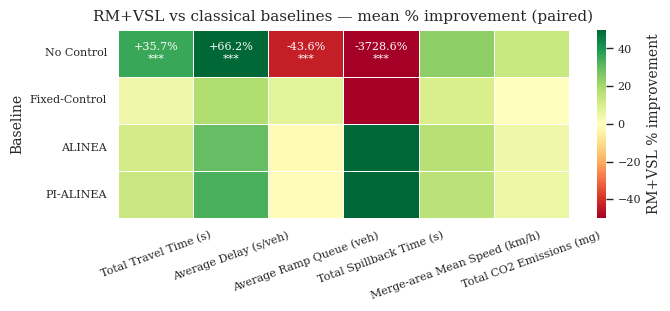

In [19]:
baselines_pct = pd.DataFrame(
    index=BASELINE_NAMES, columns=list(EFFICIENCY_METRICS), dtype=float)
baselines_sig = pd.DataFrame(
    index=BASELINE_NAMES, columns=list(EFFICIENCY_METRICS), dtype=object)
for baseline in BASELINE_NAMES:
    join = paired_join(RM_VSL_NAME, baseline, df)
    for mk in EFFICIENCY_METRICS:
        s = paired_summary(join, mk)
        baselines_pct.loc[baseline, mk] = s["pct_improvement"]
        baselines_sig.loc[baseline, mk] = significance_stars(s["wilcoxon_p"])

# Render heatmap with significance stars overlay
fig, ax = plt.subplots(figsize=(7.0, 3.2))
display_cols = [EFFICIENCY_METRICS[mk] for mk in EFFICIENCY_METRICS]
heat = baselines_pct.copy(); heat.columns = display_cols
sig  = baselines_sig.copy(); sig.columns = display_cols
annot = heat.copy().astype(object)
for r in annot.index:
    for c in annot.columns:
        v = heat.loc[r, c]
        annot.loc[r, c] = f"{v:+.1f}%\n{sig.loc[r, c]}"
sns.heatmap(heat, annot=annot.values, fmt="",
            cmap="RdYlGn", center=0, vmin=-50, vmax=50,
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "RM+VSL % improvement"}, ax=ax,
            annot_kws={"size": 8})
ax.set_title("RM+VSL vs classical baselines — mean % improvement (paired)")
ax.set_xlabel(""); ax.set_ylabel("Baseline")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show(); plt.close(fig)

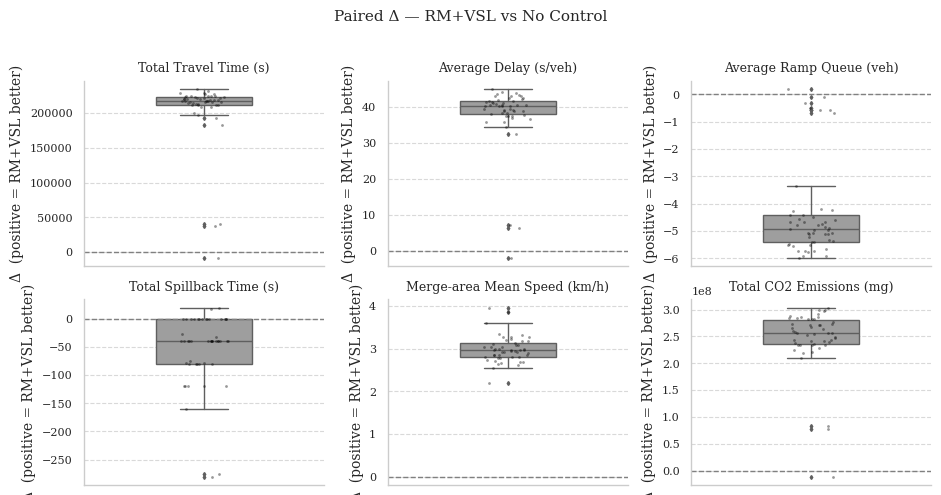

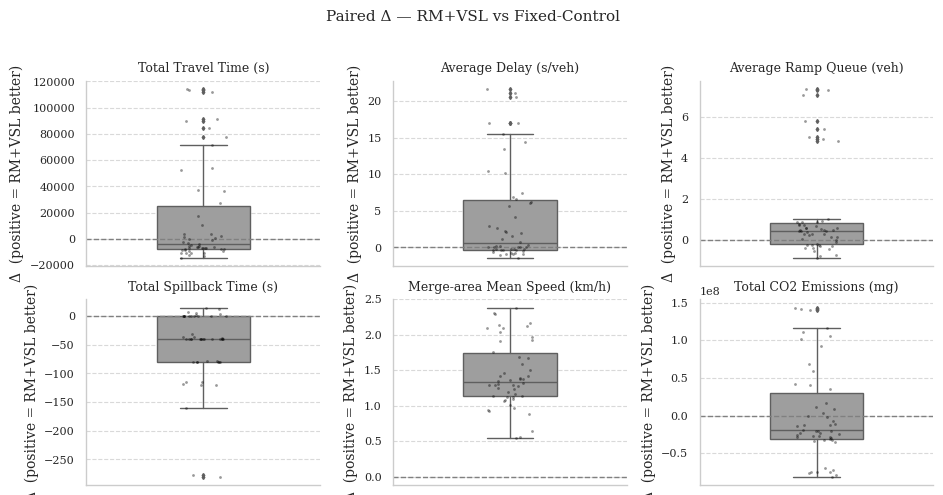

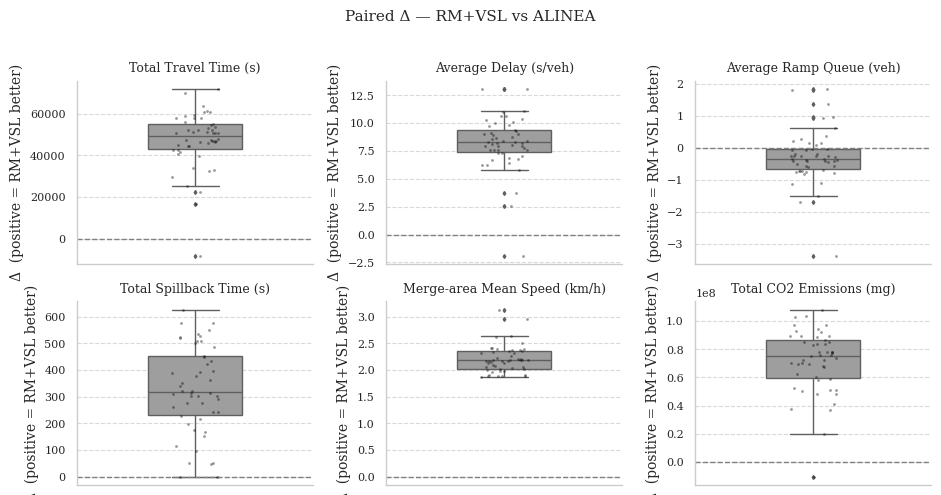

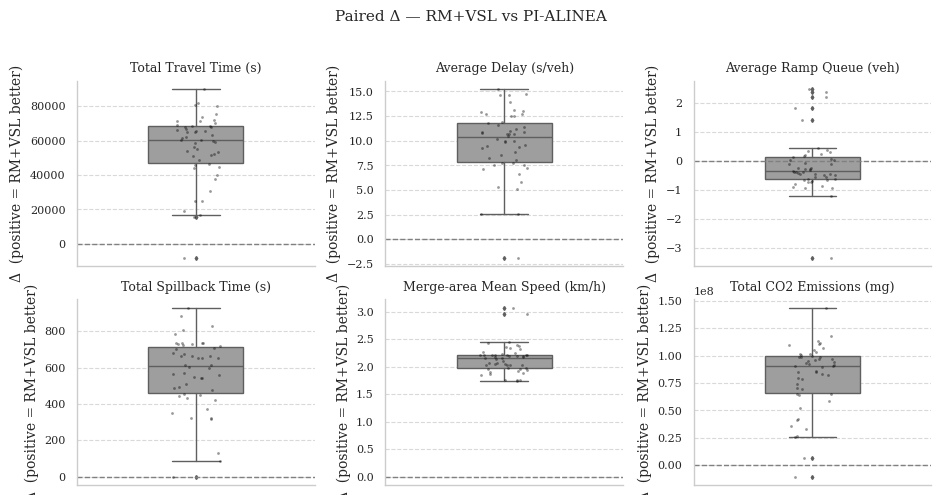

In [20]:
for baseline in BASELINE_NAMES:
    join = paired_join(RM_VSL_NAME, baseline, df)
    fig, axes = plt.subplots(2, 3, figsize=(9.5, 4.8), sharey=False)
    for ax, (mk, name) in zip(axes.ravel(), EFFICIENCY_METRICS.items()):
        a = join[f"{mk}_a"]; b = join[f"{mk}_b"]
        delta = (a - b) if mk in HIGHER_IS_BETTER else (b - a)
        sns.boxplot(y=delta, color=STRATEGY_COLORS[RM_VSL_NAME], width=0.4,
                    fliersize=2.0, linewidth=1.0, ax=ax)
        sns.stripplot(y=delta, color="black", size=2.0, alpha=0.4, jitter=True, ax=ax)
        ax.axhline(0, color="grey", linestyle="--", linewidth=1)
        ax.set_title(name, fontsize=9)
        ax.set_ylabel("Δ  (positive = RM+VSL better)")
    fig.suptitle(f"Paired Δ — RM+VSL vs {baseline}", y=1.02, fontsize=11)
    plt.tight_layout(); plt.show(); plt.close(fig)

## 8. Demand-Conditioned Performance

Aggregates can mask scenario-specific failure modes. This section breaks performance down
by the nine demand cells of the (mainline × on-ramp) grid.

/home/yassermessahli/Documents/GitHub/Ramp-Metering-PFE/.venv/lib/python3.10/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


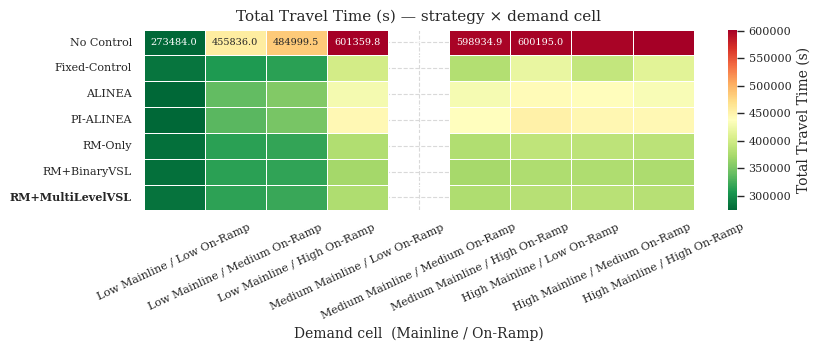

/home/yassermessahli/Documents/GitHub/Ramp-Metering-PFE/.venv/lib/python3.10/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


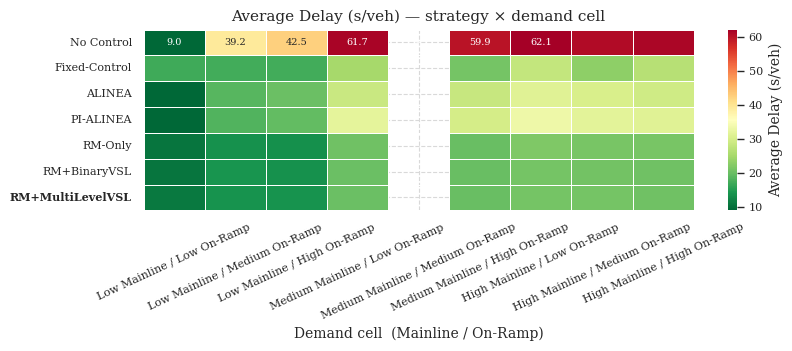

/home/yassermessahli/Documents/GitHub/Ramp-Metering-PFE/.venv/lib/python3.10/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


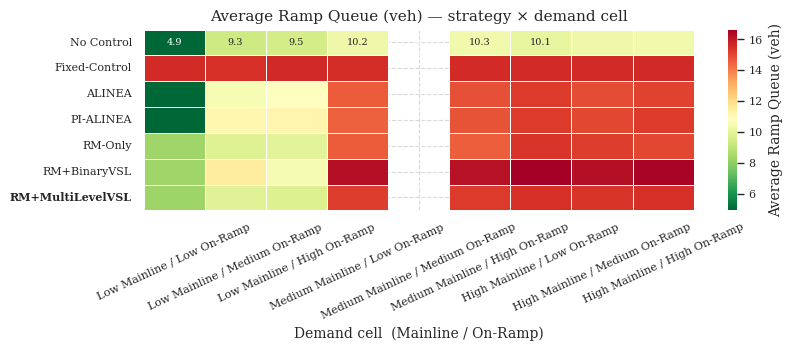

/home/yassermessahli/Documents/GitHub/Ramp-Metering-PFE/.venv/lib/python3.10/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


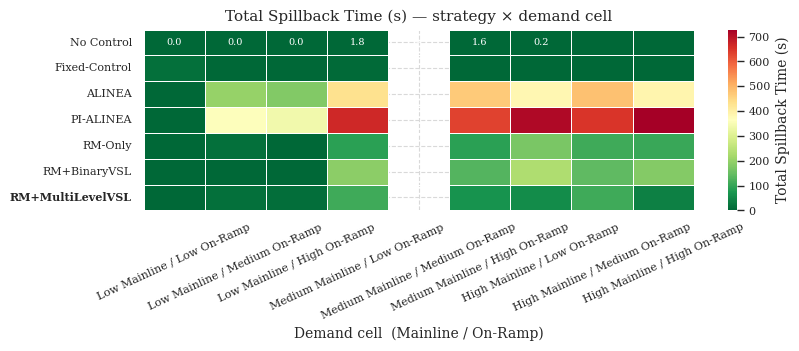

/home/yassermessahli/Documents/GitHub/Ramp-Metering-PFE/.venv/lib/python3.10/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


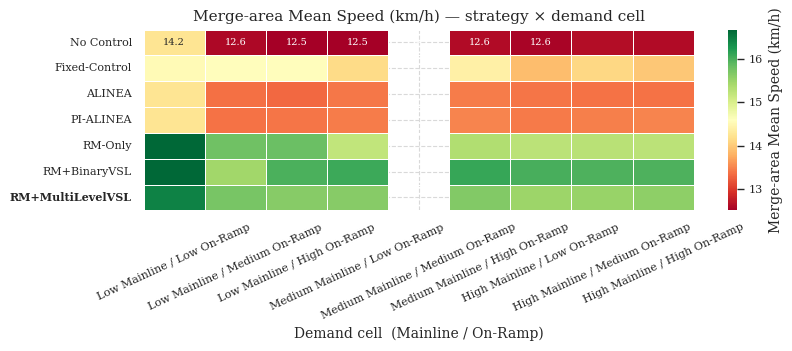

/home/yassermessahli/Documents/GitHub/Ramp-Metering-PFE/.venv/lib/python3.10/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


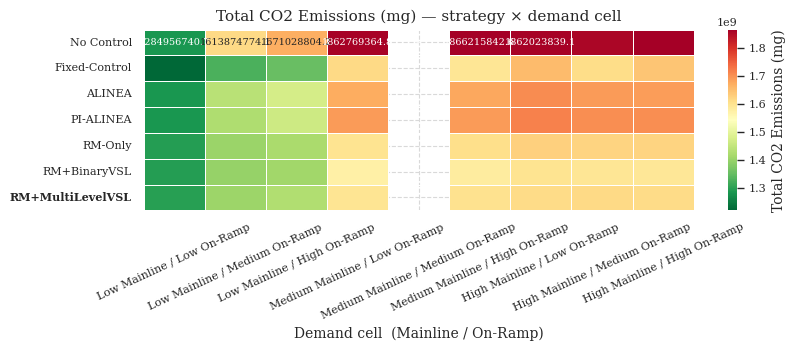

In [21]:
demand_cells = [f"{m} / {r}" for m in MAINLINE_LEVELS for r in RAMP_LEVELS]
for metric_key, metric_name in EFFICIENCY_METRICS.items():
    pivot = (df.groupby(["strategy", "demand_cell"], observed=True)[metric_key]
               .mean().unstack("demand_cell")
               .reindex(index=present_strategies, columns=demand_cells))
    cmap = "RdYlGn" if metric_key in HIGHER_IS_BETTER else "RdYlGn_r"
    fig, ax = plt.subplots(figsize=(8.5, 3.6))
    sns.heatmap(pivot, cmap=cmap, annot=True, fmt=".1f",
                annot_kws={"size": 7}, linewidths=0.4, linecolor="white",
                cbar_kws={"label": metric_name}, ax=ax)
    ax.set_title(f"{metric_name} — strategy × demand cell")
    ax.set_xlabel("Demand cell  (Mainline / On-Ramp)")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=25)
    for label in ax.get_yticklabels():
        if label.get_text() == FOCUS_STRATEGY:
            label.set_fontweight("bold")
    plt.tight_layout(); plt.show(); plt.close(fig)

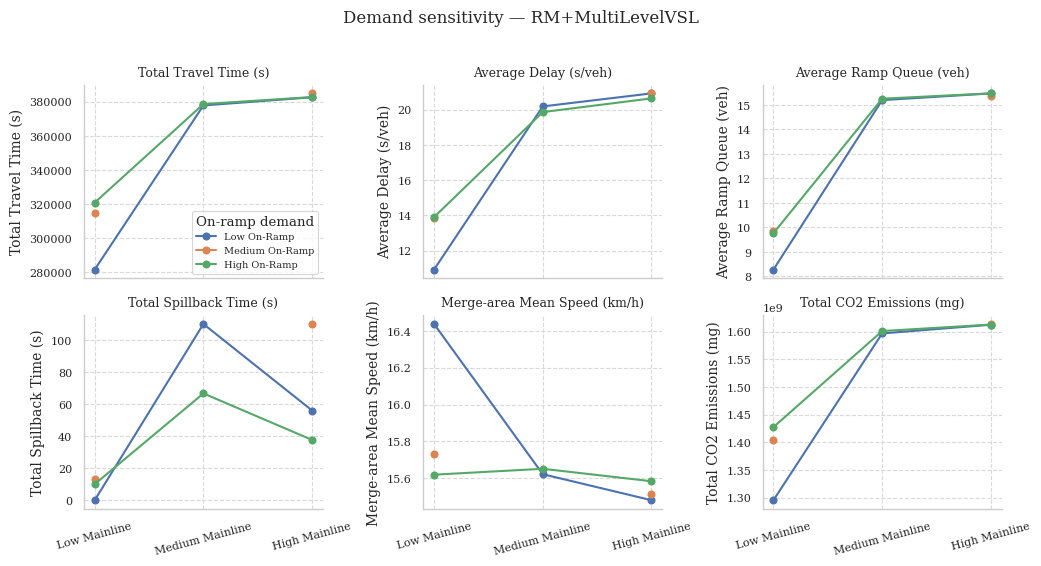

In [22]:
focus_df = df[df.strategy == FOCUS_STRATEGY]
fig, axes = plt.subplots(2, 3, figsize=(10.5, 5.5), sharex=True)
for ax, (mk, name) in zip(axes.ravel(), EFFICIENCY_METRICS.items()):
    grouped = (focus_df.groupby(["mainline_demand", "on_ramp_demand"], observed=True)[mk]
                       .mean().unstack("on_ramp_demand")
                       .reindex(index=MAINLINE_LEVELS, columns=RAMP_LEVELS))
    for r in RAMP_LEVELS:
        ax.plot(MAINLINE_LEVELS, grouped[r], marker="o", linewidth=1.5, label=r)
    ax.set_title(name, fontsize=9); ax.set_ylabel(name)
    ax.tick_params(axis="x", rotation=15)
axes[0, 0].legend(title="On-ramp demand", loc="best", fontsize=7)
fig.suptitle(f"Demand sensitivity — {FOCUS_STRATEGY}", y=1.02, fontsize=12)
plt.tight_layout(); plt.show(); plt.close(fig)

## 10. Externalities, Safety & Robustness

Improvements paid for in emissions, safety, or higher episode-to-episode variability would
undermine the contribution. This section reports those side-effects.

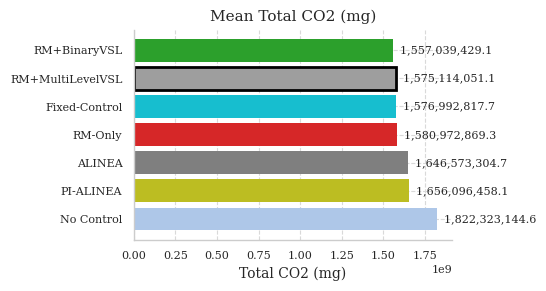

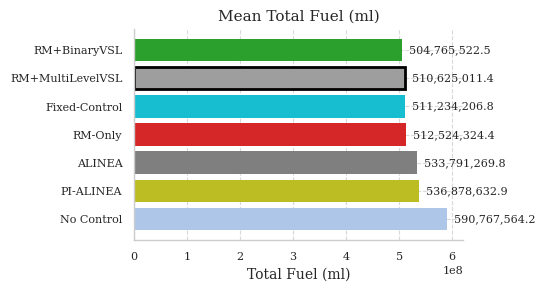

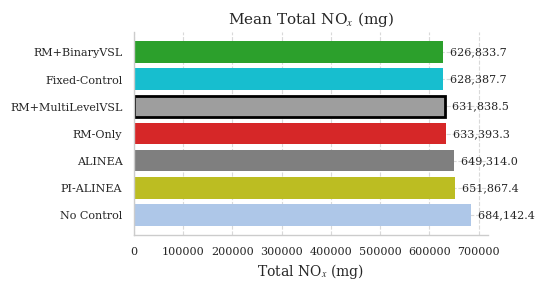

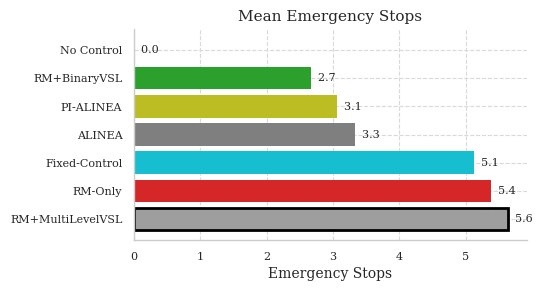

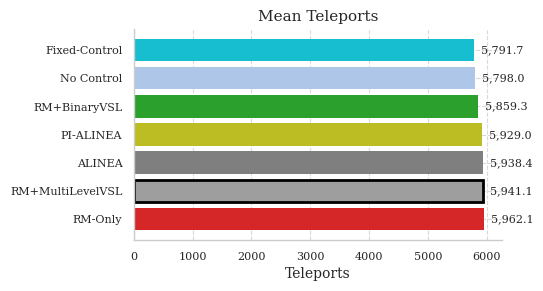

In [23]:
ext_means = (df.groupby("strategy", sort=False)[list(EXTERNALITY_METRICS)]
               .mean().reindex(present_strategies))
ext_stds  = (df.groupby("strategy", sort=False)[list(EXTERNALITY_METRICS)]
               .std(ddof=1).reindex(present_strategies))

for mk, name in EXTERNALITY_METRICS.items():
    ordered = ext_means[mk].sort_values()
    fig, ax = plt.subplots(figsize=(5.5, 3.0))
    colors = [STRATEGY_COLORS[s] for s in ordered.index]
    edges  = ["black" if s == FOCUS_STRATEGY else "none" for s in ordered.index]
    widths = [2.0     if s == FOCUS_STRATEGY else 0      for s in ordered.index]
    ax.barh(ordered.index, ordered.values, color=colors,
            edgecolor=edges, linewidth=widths)
    ax.set_title(f"Mean {name}"); ax.set_xlabel(name); ax.set_ylabel("")
    ax.invert_yaxis()
    for s, v in ordered.items():
        ax.text(v, list(ordered.index).index(s), f"  {v:,.1f}",
                va="center", fontsize=8)
    plt.tight_layout(); plt.show(); plt.close(fig)

In [24]:
ext_str = pd.DataFrame(index=present_strategies, columns=list(EXTERNALITY_METRICS),
                       dtype=object)
for s in present_strategies:
    for mk in EXTERNALITY_METRICS:
        ext_str.loc[s, mk] = f"{ext_means.loc[s, mk]:,.1f} ± {ext_stds.loc[s, mk]:,.1f}"
ext_str.columns = [EXTERNALITY_METRICS[c] for c in ext_str.columns]
display(Markdown("**Externalities — mean ± std across 50 episodes**"))
display(ext_str.style.set_caption("Lower is better for every column"))

**Externalities — mean ± std across 50 episodes**

,Total CO2 (mg),Total Fuel (ml),Total NO$_x$ (mg),Emergency Stops,Teleports
No Control,"1,822,323,144.6 ± 127,346,842.3","590,767,564.2 ± 41,284,170.7","684,142.4 ± 38,107.1",0.0 ± 0.0,"5,798.0 ± 176.1"
Fixed-Control,"1,576,992,817.7 ± 131,266,468.2","511,234,206.8 ± 42,554,584.2","628,387.7 ± 43,792.2",5.1 ± 2.3,"5,791.7 ± 329.0"
ALINEA,"1,646,573,304.7 ± 101,502,560.1","533,791,269.8 ± 32,905,646.0","649,314.0 ± 35,521.4",3.3 ± 2.2,"5,938.4 ± 187.7"
PI-ALINEA,"1,656,096,458.1 ± 108,898,492.6","536,878,632.9 ± 35,303,334.3","651,867.4 ± 37,343.9",3.1 ± 2.0,"5,929.0 ± 194.1"
RM-Only,"1,580,972,869.3 ± 89,031,376.4","512,524,324.4 ± 28,862,638.4","633,393.3 ± 33,541.2",5.4 ± 3.0,"5,962.1 ± 197.8"
RM+BinaryVSL,"1,557,039,429.1 ± 81,274,595.8","504,765,522.5 ± 26,348,024.7","626,833.7 ± 31,485.5",2.7 ± 2.7,"5,859.3 ± 161.6"
RM+MultiLevelVSL,"1,575,114,051.1 ± 85,295,022.0","510,625,011.4 ± 27,651,362.9","631,838.5 ± 32,583.1",5.6 ± 2.2,"5,941.1 ± 181.7"


In [25]:
ext_join = paired_join(RM_VSL_NAME, RM_ONLY_NAME, df)
ext_rows = []
for mk, name in EXTERNALITY_METRICS.items():
    if f"{mk}_a" not in ext_join.columns or f"{mk}_b" not in ext_join.columns:
        continue
    # All externality metrics are lower-is-better; sign so positive Δ = improvement
    a = ext_join[f"{mk}_a"]; b = ext_join[f"{mk}_b"]
    delta = b - a
    try:
        _, p = stats.wilcoxon(delta, zero_method="wilcox", alternative="two-sided") \
               if (delta != 0).any() else (None, np.nan)
    except ValueError:
        p = np.nan
    ext_rows.append({
        "Externality":     name,
        "Δ̄ (RM-Only − RM+VSL)": float(delta.mean()),
        "σ_Δ":             float(delta.std(ddof=1)),
        "% Improvement":   pct_improvement(a.mean(), b.mean(), mk),
        "Wilcoxon p":      float(p) if p is not None else np.nan,
        "Sig.":            significance_stars(p) if p is not None else "n/a",
        "Wins / 50":       int((delta > 0).sum()),
    })
ext_paired_df = pd.DataFrame(ext_rows).set_index("Externality")
display(Markdown("**Paired ablation on externalities** — RM+VSL vs RM-Only. "
                 "Positive Δ̄ and positive % improvement mean RM+VSL pollutes / endangers less."))
display(
    ext_paired_df.style.format({
        "Δ̄ (RM-Only − RM+VSL)": "{:+.2f}",
        "σ_Δ": "{:.2f}",
        "% Improvement": "{:+.2f}%",
        "Wilcoxon p":    "{:.3g}",
    }).background_gradient(cmap="RdYlGn", subset=["% Improvement"], vmin=-30, vmax=30)
)

**Paired ablation on externalities** — RM+VSL vs RM-Only. Positive Δ̄ and positive % improvement mean RM+VSL pollutes / endangers less.

,Δ̄ (RM-Only − RM+VSL),σ_Δ,% Improvement,Wilcoxon p,Sig.,Wins / 50
Externality,,,,,,
Total CO2 (mg),+5858818.19,12142171.79,+0.37%,0.0024,**,34
Total Fuel (ml),+1899312.99,3936301.18,+0.37%,0.0024,**,34
Total NO$_x$ (mg),+1554.77,4287.15,+0.25%,0.0187,*,33
Emergency Stops,-0.26,3.33,-4.83%,0.474,ns,19
Teleports,+21.00,38.05,+0.35%,0.000758,***,34


In [26]:
robust_metrics = list(EFFICIENCY_METRICS) + list(EXTERNALITY_METRICS)
robust_metrics = list(dict.fromkeys(robust_metrics))
means_all = df.groupby("strategy", sort=False)[robust_metrics].mean().reindex(present_strategies)
stds_all  = df.groupby("strategy", sort=False)[robust_metrics].std(ddof=1).reindex(present_strategies)
cov_all = (stds_all / means_all.abs())
cov_disp = cov_all.copy()
cov_disp.columns = [
    EFFICIENCY_METRICS.get(c, EXTERNALITY_METRICS.get(c, c)) for c in cov_disp.columns
]
display(Markdown("**Coefficient of variation (lower = more consistent across episodes)**"))
display(
    cov_disp.style.format("{:.3f}")
    .background_gradient(cmap="RdYlGn_r", axis=0)
    .set_caption("Robustness comparison across the 6 controllers")
)

**Coefficient of variation (lower = more consistent across episodes)**

,Total Travel Time (s),Average Delay (s/veh),Average Ramp Queue (veh),Total Spillback Time (s),Merge-area Mean Speed (km/h),Total CO2 Emissions (mg),Total Fuel (ml),Total NO$_x$ (mg),Emergency Stops,Teleports
strategy,,,,,,,,,,
No Control,0.127,0.205,0.092,2.982,0.022,0.070,0.070,0.056,nan,0.030
Fixed-Control,0.140,0.338,0.009,2.050,0.034,0.083,0.083,0.070,0.454,0.057
ALINEA,0.095,0.184,0.159,0.445,0.013,0.062,0.062,0.055,0.645,0.032
PI-ALINEA,0.106,0.208,0.152,0.319,0.012,0.066,0.066,0.057,0.658,0.033
RM-Only,0.080,0.171,0.152,1.026,0.022,0.056,0.056,0.053,0.556,0.033
RM+BinaryVSL,0.074,0.153,0.145,1.030,0.014,0.052,0.052,0.050,1.017,0.028
RM+MultiLevelVSL,0.075,0.154,0.154,1.164,0.018,0.054,0.054,0.052,0.390,0.031
